# Holt Winters

In [83]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [84]:
df = pd.read_excel("Data IKM Magang.xlsx")

df.head()

,No,Tanggal,Persyaratan,Prosedur pelayanan,Waktu,Biaya/tarif,Produk pelayanan,Kompetensi/kemampuan,Perilaku petugas sopan dan ramah,Kualitas sarana dan prasarana,Penanganan pengaduan,IKM Konversi,Jumlah Orang
0,1,2023-01-01,"3,80","3,76","3,99","3,77","4,00","3,81","3,81","3,89","3,80","96,19",277
1,2,2023-02-01,"3,92","3,92","3,88","4,00","3,92","3,96","3,88","3,83","3,96","97,92",24
2,3,2023-03-01,"3,57","3,59","3,54","4,00","3,54","3,54","3,59","3,51","3,53","90,01",189
3,4,2023-04-01,"3,74","3,74","3,69","4,00","3,68","3,71","3,78","3,69","3,68","93,64",114
4,5,2023-05-01,"3,58","3,56","3,55","4,00","3,48","3,51","3,56","3,43","3,44","89,16",227


In [85]:
df['IKM Konversi'] = (
    df['IKM Konversi']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

df['Tanggal'] = pd.to_datetime(df['Tanggal'])

df = df.sort_values('Tanggal')

In [86]:
ts = df[['Tanggal','IKM Konversi']].copy()

ts = ts.set_index('Tanggal')

ts.head()

,IKM Konversi
Tanggal,
2023-01-01,96.19
2023-02-01,97.92
2023-03-01,90.01
2023-04-01,93.64
2023-05-01,89.16


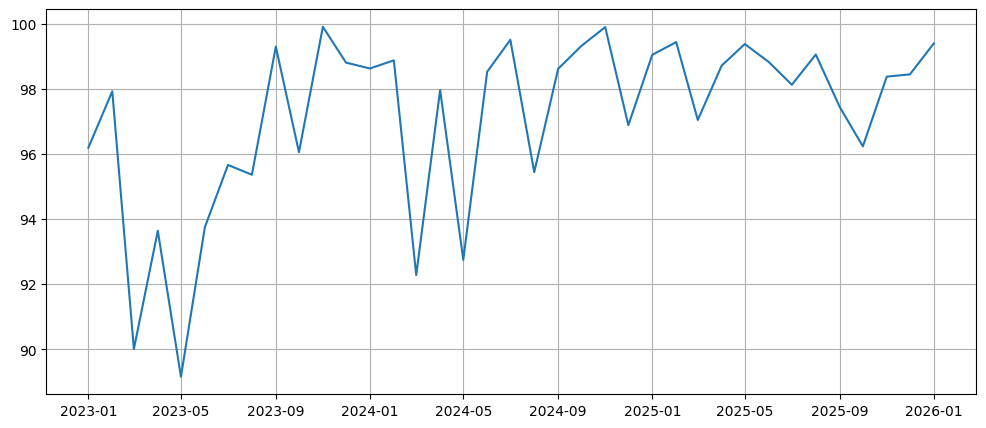

In [87]:
plt.figure(figsize=(12,5))
plt.plot(ts['IKM Konversi'])
plt.grid(True)
plt.show()

<Figure size 1000x500 with 0 Axes>

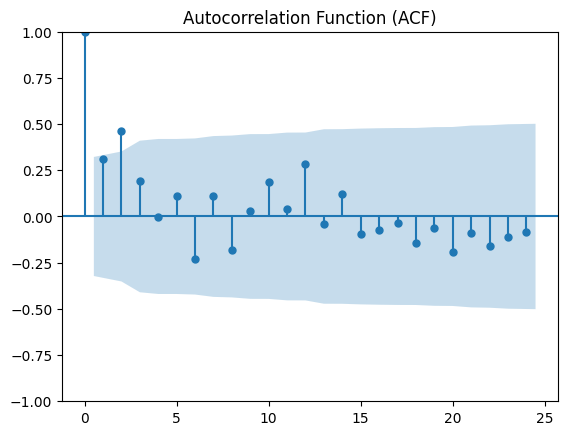

In [88]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10,5))
plot_acf(
    ts['IKM Konversi'],
    lags=24,
    alpha=0.05
)

plt.title('Autocorrelation Function (ACF)')
plt.show()

In [89]:
from statsmodels.tsa.stattools import acf

acf_values = acf(
    ts['IKM Konversi'],
    nlags=24
)

acf_df = pd.DataFrame({
    'Lag': range(len(acf_values)),
    'ACF': acf_values
})

print(acf_df)

    Lag       ACF
0     0  1.000000
1     1  0.309024
2     2  0.463156
3     3  0.192747
4     4 -0.005248
5     5  0.111438
6     6 -0.228569
7     7  0.109563
8     8 -0.181464
9     9  0.031658
10   10  0.186014
11   11  0.037953
12   12  0.282040
13   13 -0.041819
14   14  0.120866
15   15 -0.092886
16   16 -0.074589
17   17 -0.033467
18   18 -0.143005
19   19 -0.061810
20   20 -0.190700
21   21 -0.090774
22   22 -0.159570
23   23 -0.109932
24   24 -0.084525


In [90]:
train_size = int(len(ts) * 0.8)

train = ts.iloc[:train_size]

test = ts.iloc[train_size:]

print("Train :", len(train))
print("Test  :", len(test))

Train : 29
Test  : 8


In [91]:
model = ExponentialSmoothing(
    train['IKM Konversi'],
    trend='add',
    seasonal='add',
    seasonal_periods=12
)

fit_model = model.fit()

c:\Users\LENOVO\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [92]:
pred_test = fit_model.forecast(
    len(test)
)

In [93]:
mae = mean_absolute_error(
    test['IKM Konversi'],
    pred_test
)

rmse = np.sqrt(
    mean_squared_error(
        test['IKM Konversi'],
        pred_test
    )
)

mape = np.mean(
    np.abs(
        (test['IKM Konversi'] - pred_test)
        / test['IKM Konversi']
    )
) * 100

r2 = r2_score(
    test['IKM Konversi'],
    pred_test
)

print("================================")
print("HASIL EVALUASI")
print("================================")

print("MAE  :", mae,)
print("RMSE :", rmse,)
print("MAPE :", (mape) , "%")

HASIL EVALUASI
MAE  : 3.1155997894817116
RMSE : 3.5744593373131703
MAPE : 3.1831260007867805 %


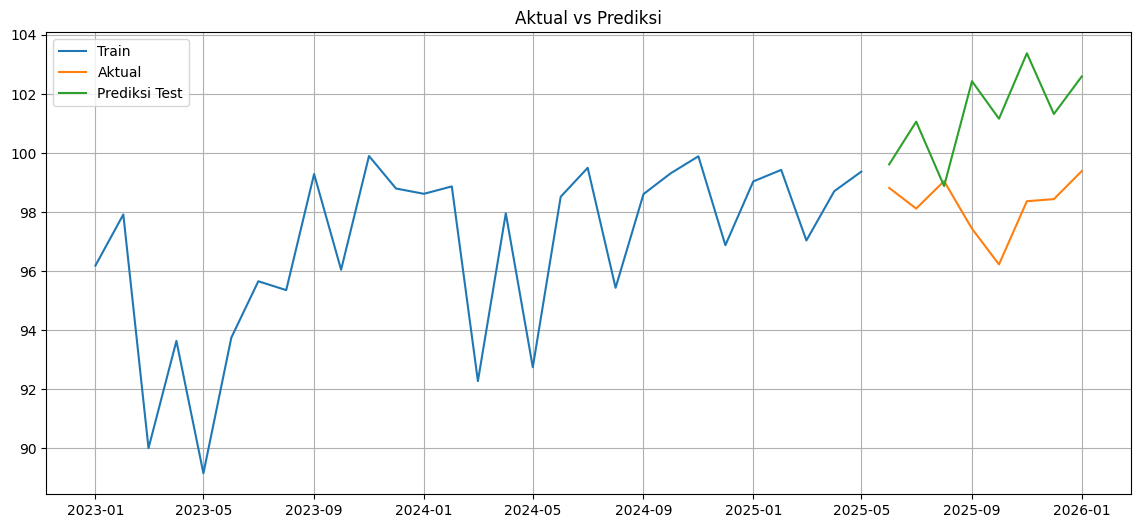

In [94]:
plt.figure(figsize=(14,6))

plt.plot(
    train.index,
    train['IKM Konversi'],
    label='Train'
)

plt.plot(
    test.index,
    test['IKM Konversi'],
    label='Aktual'
)

plt.plot(
    test.index,
    pred_test,
    label='Prediksi Test'
)

plt.title("Aktual vs Prediksi")

plt.legend()
plt.grid(True)

plt.show()

In [95]:
final_model = ExponentialSmoothing(
    ts['IKM Konversi'],
    trend='add',
    seasonal='add',
    seasonal_periods=12
)

final_fit = final_model.fit()


c:\Users\LENOVO\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [96]:
fitted_values = final_fit.fittedvalues

In [97]:
historical_fit = pd.DataFrame({
    'Tanggal': ts.index,
    'IKM Aktual': ts['IKM Konversi'],
    'Fitting Holt': fitted_values
})

historical_fit

,Tanggal,IKM Aktual,Fitting Holt
Tanggal,,,
2023-01-01,2023-01-01,96.19,95.969957
2023-02-01,2023-02-01,97.92,96.779007
2023-03-01,2023-03-01,90.01,91.593957
2023-04-01,2023-04-01,93.64,94.636162
2023-05-01,2023-05-01,89.16,91.237712
2023-06-01,2023-06-01,93.75,93.697366
2023-07-01,2023-07-01,95.66,94.447750
2023-08-01,2023-08-01,95.36,93.777303
2023-09-01,2023-09-01,99.29,96.224629


In [98]:
forecast_12 = final_fit.forecast(11)

In [99]:
future_dates = pd.date_range(
    start=ts.index.max() + pd.DateOffset(months=1),
    periods=11,
    freq='MS'
)

In [100]:
forecast_df = pd.DataFrame({
    'Tanggal': future_dates,
    'Forecast Holt': forecast_12.values
})

forecast_df

,Tanggal,Forecast Holt
0,2026-02-01,99.912899
1,2026-03-01,94.282839
2,2026-04-01,97.942818
3,2026-05-01,94.932890
4,2026-06-01,98.202892
5,2026-07-01,98.932748
6,2026-08-01,97.789500
7,2026-09-01,99.619544
8,2026-10-01,98.369361
9,2026-11-01,100.559523


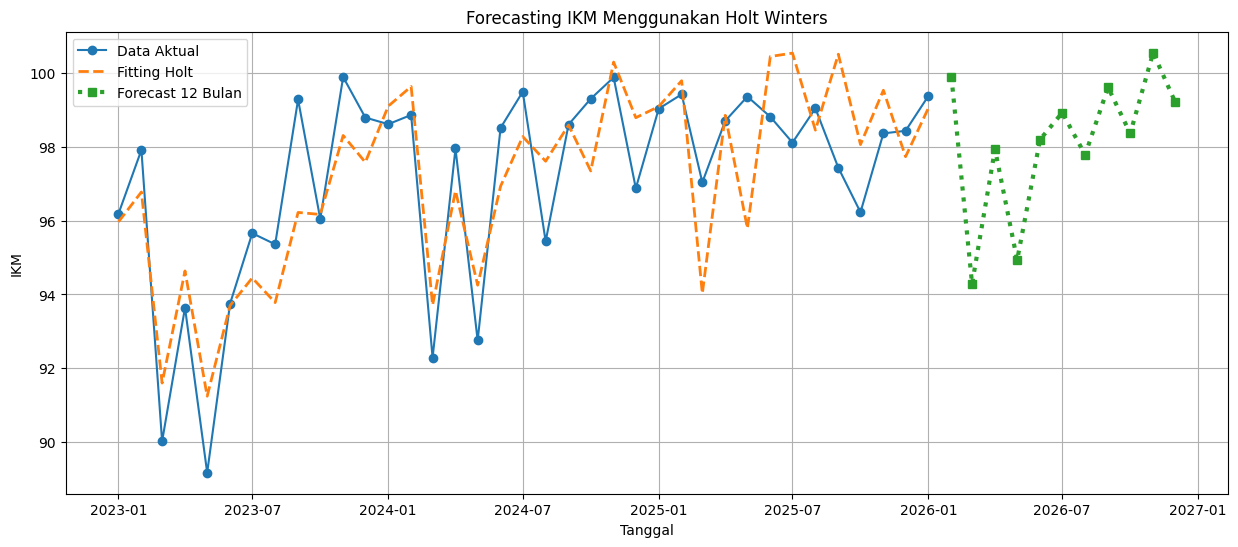

In [101]:
plt.figure(figsize=(15,6))

plt.plot(
    historical_fit['Tanggal'],
    historical_fit['IKM Aktual'],
    marker='o',
    label='Data Aktual'
)

plt.plot(
    historical_fit['Tanggal'],
    historical_fit['Fitting Holt'],
    linestyle='--',
    linewidth=2,
    label='Fitting Holt'
)

plt.plot(
    forecast_df['Tanggal'],
    forecast_df['Forecast Holt'],
    marker='s',
    linestyle=':',
    linewidth=3,
    label='Forecast 12 Bulan'
)

plt.title(
    'Forecasting IKM Menggunakan Holt Winters'
)

plt.xlabel('Tanggal')

plt.ylabel('IKM')

plt.legend()

plt.grid(True)

plt.show()

In [102]:
dashboard_historis = pd.DataFrame({
    'Tanggal': historical_fit['Tanggal'],
    'IKM Konversi': historical_fit['IKM Aktual'],
    'Fitting': historical_fit['Fitting Holt'],
    'Forecast': None
})

dashboard_forecast = pd.DataFrame({
    'Tanggal': forecast_df['Tanggal'],
    'IKM Konversi': None,
    'Fitting': None,
    'Forecast': forecast_df['Forecast Holt']
})

dashboard_final = pd.concat(
    [dashboard_historis,
     dashboard_forecast],
    ignore_index=True
)

dashboard_final

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20204\2590573204.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dashboard_final = pd.concat(


,Tanggal,IKM Konversi,Fitting,Forecast
0,2023-01-01,96.19,95.969957,NaN
1,2023-02-01,97.92,96.779007,NaN
2,2023-03-01,90.01,91.593957,NaN
3,2023-04-01,93.64,94.636162,NaN
4,2023-05-01,89.16,91.237712,NaN
5,2023-06-01,93.75,93.697366,NaN
6,2023-07-01,95.66,94.447750,NaN
7,2023-08-01,95.36,93.777303,NaN
8,2023-09-01,99.29,96.224629,NaN
9,2023-10-01,96.05,96.170000,NaN


In [103]:
'''dashboard_final.to_excel(
    "Dashboard1.xlsx",
    index=False
)

print(
    "File Dashboard_Holt_Winters.xlsx berhasil disimpan"
)'''

'dashboard_final.to_excel(\n    "Dashboard1.xlsx",\n    index=False\n)\n\nprint(\n    "File Dashboard_Holt_Winters.xlsx berhasil disimpan"\n)'